# CreditGuard: Credit Risk Prediction System
## Machine Learning Pipeline for Loan Default Risk Assessment

This notebook implements an end-to-end ML pipeline to predict loan default risk using XGBoost with SMOTE balancing. The model is then deployed via a Streamlit web application for real-time risk assessment.

### Project Components:
1. **Data Loading & Cleaning** - Load dataset and handle outliers/missing values
2. **Exploratory Data Analysis** - Visualize distributions and relationships
3. **Feature Engineering** - Encode categorical variables
4. **Model Training** - Train XGBoost with class balancing
5. **Model Evaluation** - Assess performance with confusion matrix and classification metrics
6. **Feature Importance** - Identify key risk factors
7. **Model Explainability** - SHAP analysis for interpretability
8. **Model Deployment** - Save model for production use and Streamlit app

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib
import shap

df = pd.read_csv('credit_risk_dataset.csv')
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 32581 rows, 12 columns


## 2. Data Cleaning & Preprocessing

### Outlier Removal
- Remove records with `person_age ≥ 100` (unrealistic)
- Remove records with `person_emp_length ≥ 60` (unrealistic)

### Missing Value Imputation
- Fill `loan_int_rate` with median
- Fill `person_emp_length` with median

In [2]:
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 60)]

df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

print("Data Cleaning Complete. Missing values:")
print(df.isnull().sum())

Data Cleaning Complete. Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


C:\Users\pisin\AppData\Local\Temp\ipykernel_26720\143285158.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
C:\Users\pisin\AppData\Local\Temp\ipykernel_26720\143285158.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

## 3. Exploratory Data Analysis

### Target Variable Distribution
Examine the balance between safe loans (0) and defaulted loans (1)

C:\Users\pisin\AppData\Local\Temp\ipykernel_26720\1058932648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='magma', ax=axes[0])


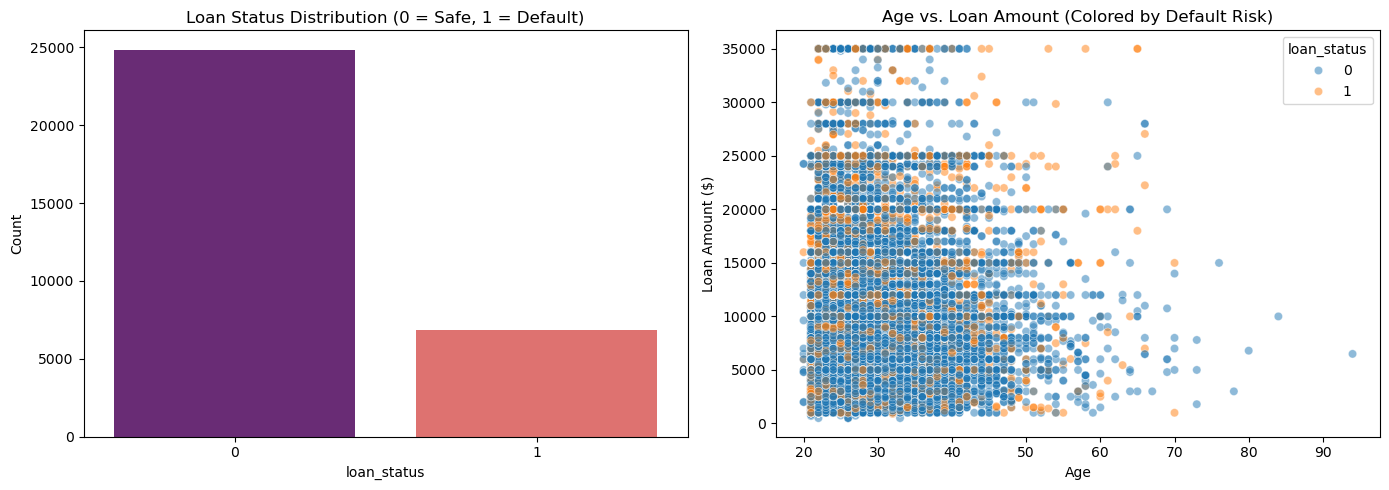

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='loan_status', data=df, palette='magma', ax=axes[0])
axes[0].set_title('Loan Status Distribution (0 = Safe, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Count')

sns.scatterplot(x='person_age', y='loan_amnt', hue='loan_status', data=df, alpha=0.5, ax=axes[1])
axes[1].set_title('Age vs. Loan Amount (Colored by Default Risk)', fontsize=12)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

### Categorical Encoding
- One-hot encode categorical variables with `drop_first=True` to avoid multicollinearity (dummy variable trap)
- Separate features (X) and target (y)
- Train/test split: 80/20

In [4]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Class Imbalance Handling

### SMOTE (Synthetic Minority Over-sampling Technique)
- Generate synthetic samples for the minority class (defaults) to balance training data
- Applied only to training set to prevent data leakage

In [5]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Original Training Set Balance:")
print(y_train.value_counts())
print("\nBalanced Training Set:")
print(y_train_balanced.value_counts())

Original Training Set Balance:
loan_status
0    19891
1     5452
Name: count, dtype: int64

Balanced Training Set:
loan_status
0    19891
1    19891
Name: count, dtype: int64


## 6. Model Training

### XGBoost Classifier Configuration
- **n_estimators**: 150 boosting rounds
- **max_depth**: 5 (controls tree complexity)
- **learning_rate**: 0.1 (step size for updates)
- **eval_metric**: logloss (binary classification)

Train on balanced dataset to prevent bias toward majority class

In [6]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)
print("✅ Model trained successfully!")

✅ Model trained successfully!


## 7. Model Evaluation

### Confusion Matrix & Classification Metrics
- **True Negatives (TN)**: Correctly predicted safe loans
- **False Positives (FP)**: Safe loans incorrectly flagged as risky (Type I error)
- **False Negatives (FN)**: Defaults missed by model (Type II error)
- **True Positives (TP)**: Correctly predicted defaults

### Key Metrics:
- **Precision**: TP / (TP + FP) — Of loans flagged as risky, how many actually default?
- **Recall**: TP / (TP + FN) — Of actual defaults, how many does the model catch?
- **F1-Score**: Harmonic mean of precision and recall

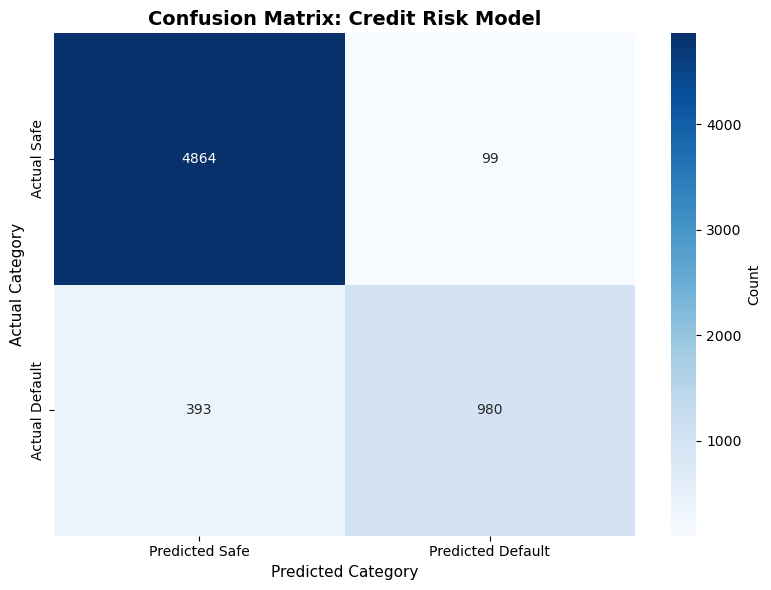

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      4963
           1       0.91      0.71      0.80      1373

    accuracy                           0.92      6336
   macro avg       0.92      0.85      0.88      6336
weighted avg       0.92      0.92      0.92      6336



In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Safe', 'Predicted Default'],
            yticklabels=['Actual Safe', 'Actual Default'],
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_title('Confusion Matrix: Credit Risk Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Category', fontsize=11)
ax.set_xlabel('Predicted Category', fontsize=11)

plt.tight_layout()
plt.show()

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

## 8. Feature Importance Analysis

### Top Risk Factors
Identifies which features have the strongest influence on loan default predictions. Features with higher importance scores contribute more to the model's decision-making process.

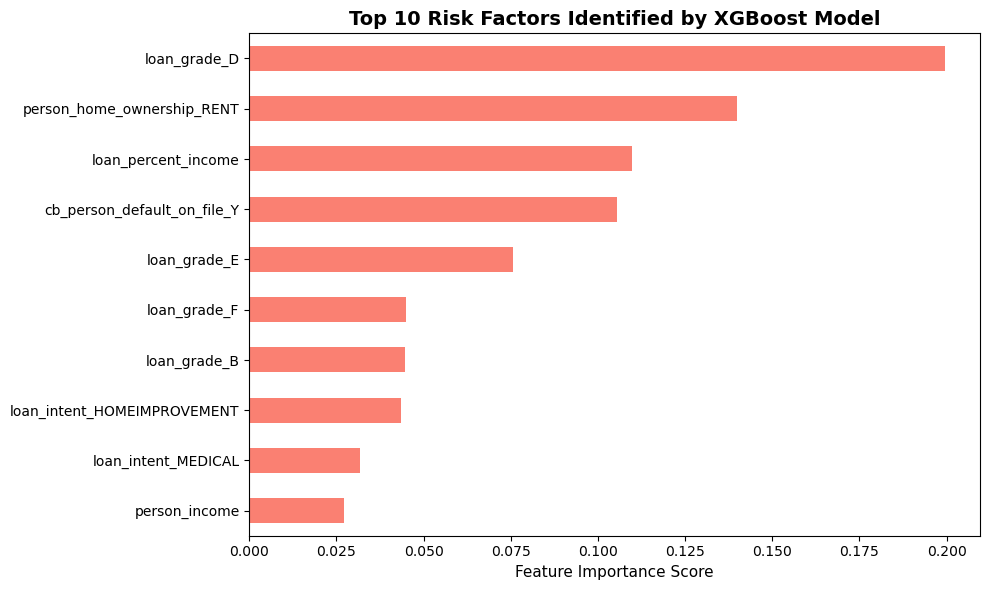

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(model.feature_importances_, index=X.columns).nlargest(10)
importances.plot(kind='barh', color='salmon', ax=ax)

ax.set_title('Top 10 Risk Factors Identified by XGBoost Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Model Explainability with SHAP

### SHAP (SHapley Additive exPlanations) Analysis
Provides a principled approach to explaining individual predictions. Each feature's contribution to moving the prediction from the base value is visualized.

**Interpretation**:
- Red bars push prediction toward default (high risk)
- Blue bars push prediction away from default (low risk)
- Bar length indicates magnitude of impact

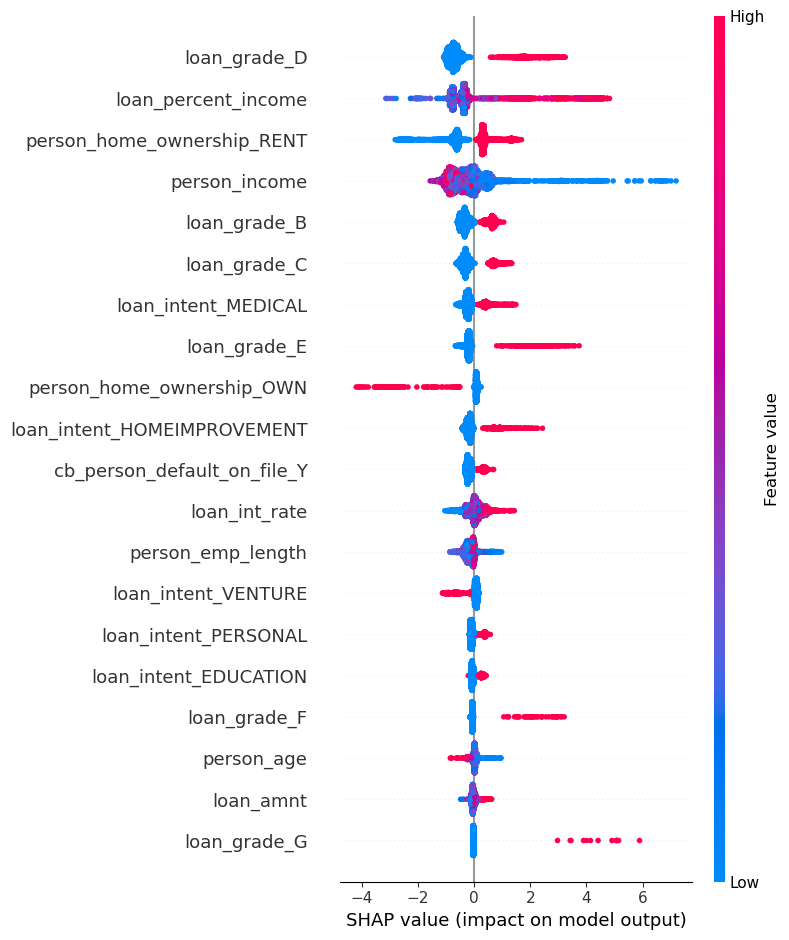

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)

## 10. Model Persistence

Save the trained model and feature column names for deployment in the Streamlit application

In [10]:
joblib.dump(model, 'credit_risk_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("✅ Model and metadata saved successfully!")

✅ Model and metadata saved successfully!


## 11. Individual Risk Assessment Function

Utility function for analyzing a single customer's risk profile against actual outcomes

In [11]:
def assess_credit_risk(customer_index):
    customer_data = X_test.iloc[[customer_index]]
    actual_status = y_test.iloc[customer_index]
    
    prediction = model.predict(customer_data)[0]
    probability = model.predict_proba(customer_data)[0][1]
    
    decision = "🔴 HIGH RISK (Reject)" if prediction == 1 else "🟢 LOW RISK (Approve)"
    outcome = "❌ Defaulted" if actual_status == 1 else "✅ Paid Back"
    
    print("="*45)
    print(f"Customer Risk Analysis (Index {customer_index})")
    print("="*45)
    print(f"Model Decision    : {decision}")
    print(f"Default Risk      : {probability*100:.2f}%")
    print(f"Actual Outcome    : {outcome}")
    print("="*45)

## 12. Streamlit Application

### Interactive Web Dashboard for Real-Time Risk Prediction

The following cell generates the Streamlit application code that creates an interactive interface for credit risk assessment.

**Features**:
- Numeric input sliders for age, employment length, interest rate
- Text inputs for income and loan amount
- Dropdown menus for categorical features
- Real-time risk assessment with confidence scores
- Visual feedback with color-coded recommendations

In [12]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('credit_risk_model.pkl')
cols = joblib.load('model_columns.pkl')

st.set_page_config(page_title="CreditGuard", page_icon="🏦", layout="wide")
st.title("🏦 CreditGuard: Credit Risk Predictor")
st.markdown("**Intelligent Loan Default Risk Assessment System**")

col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 Applicant Information")
    age = st.slider("Age", 18, 100, 35, step=1)
    income = st.number_input("Annual Income ($)", value=50000, step=1000, min_value=0)
    emp_length = st.slider("Employment Length (years)", 0, 40, 5, step=1)

with col2:
    st.subheader("💰 Loan Details")
    loan_amount = st.number_input("Loan Amount ($)", value=15000, step=500, min_value=0)
    int_rate = st.slider("Interest Rate (%)", 5.0, 25.0, 12.0, step=0.5)
    cred_hist_length = st.slider("Credit History Length (years)", 1, 30, 7, step=1)

st.divider()

col3, col4 = st.columns(2)

with col3:
    st.subheader("🏠 Personal Details")
    home_ownership = st.selectbox("Home Ownership", ["RENT", "OWN", "MORTGAGE", "OTHER"])
    loan_intent = st.selectbox("Loan Intent", ["PERSONAL", "EDUCATION", "MEDICAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"])

with col4:
    st.subheader("📋 Credit Status")
    loan_grade = st.selectbox("Loan Grade", ["A", "B", "C", "D", "E", "F", "G"])
    default_on_file = st.selectbox("Previous Default on File?", ["No", "Yes"])

st.divider()

loan_percent_income = (loan_amount / income) if income > 0 else 0
st.metric("Loan-to-Income Ratio", f"{loan_percent_income:.1%}")

if st.button("🔍 Calculate Risk Assessment", use_container_width=True, type="primary"):
    full_input = pd.DataFrame(0, index=[0], columns=cols)
    
    full_input['person_age'] = age
    full_input['person_income'] = income
    full_input['person_emp_length'] = emp_length
    full_input['loan_amnt'] = loan_amount
    full_input['loan_int_rate'] = int_rate
    full_input['loan_percent_income'] = loan_percent_income
    full_input['cb_person_cred_hist_length'] = cred_hist_length

    grade_col = f'loan_grade_{loan_grade}'
    if grade_col in full_input.columns:
        full_input[grade_col] = 1

    intent_col = f'loan_intent_{loan_intent}'
    if intent_col in full_input.columns:
        full_input[intent_col] = 1

    ownership_col = f'person_home_ownership_{home_ownership}'
    if ownership_col in full_input.columns:
        full_input[ownership_col] = 1

    if default_on_file == "Yes" and 'cb_person_default_on_file_Y' in full_input.columns:
        full_input['cb_person_default_on_file_Y'] = 1

    prediction = model.predict(full_input)[0]
    probability = model.predict_proba(full_input)[0][1]

    st.divider()
    st.subheader("📈 Risk Assessment Results")
    
    col_result1, col_result2 = st.columns(2)
    
    if prediction == 1:
        with col_result1:
            st.error(f"🔴 **HIGH RISK**", icon="⚠️")
        with col_result2:
            st.metric("Default Probability", f"{probability:.1%}")
        st.warning("**Recommendation: REJECT** this loan application", icon="🚫")
    else:
        with col_result1:
            st.success(f"🟢 **LOW RISK**", icon="✅")
        with col_result2:
            st.metric("Default Probability", f"{probability:.1%}")
        st.success("**Recommendation: APPROVE** this loan application", icon="✅")

Overwriting app.py


## 13. Run Streamlit Application

Execute the following command in your terminal to launch the web application:

```bash
streamlit run app.py
```

The application will be available at `http://localhost:8501`

In [ ]:
!streamlit run app.py